# Markov chain sequence simulation

The local match positions have either a normal or uniform distribution across the query

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
ref_size="250Mb"

In [223]:
dtype = "normal"
er_rates = [0.06, 0.08, 0.1]
data = pd.read_csv(ref_size + "/" + dtype + "/valik_table1.tsv", sep = "\t")
data.head()

,Unnamed: 0,error_rate,adapt_cutoff,entropy_cutoff,search time (sec),repeat queries,repeat lookups,missed (%)
0,0,0.02,0.2,1.0,20.108,0,0,0.0
1,1,0.02,0.4,1.0,20.657,0,0,0.0
2,2,0.02,0.6,1.0,20.442,0,0,0.0
3,3,0.02,0.8,1.0,20.662,0,0,0.0
4,4,0.02,1.0,1.0,20.163,0,0,0.0


In [224]:
XXSMALL_SIZE = 8
XSMALL_SIZE = 10
SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

## Local match position distribution

In [170]:
normal = pd.read_csv(ref_size + "/normal/ground_truth/rep0_e0.1.tsv", sep = "\t", header = None)
normal.columns = ["begin", "end"]
normal.drop(["end"], axis = 1, inplace = True)

In [171]:
uniform = pd.read_csv(ref_size + "/uniform/ground_truth/rep0_e0.1.tsv", sep = "\t", header = None)
uniform.columns = ["begin", "end"]
uniform.drop(["end"], axis = 1, inplace = True)

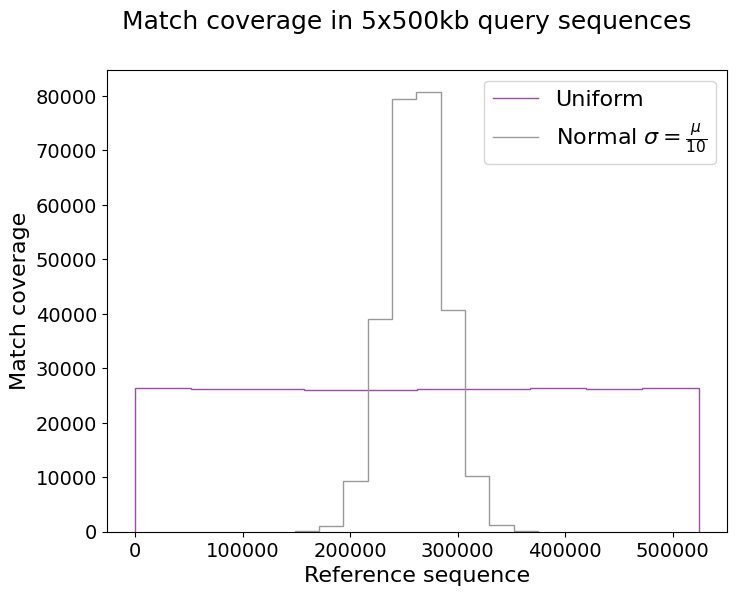

In [172]:
fig, ax = plt.subplots(1,1)
fig.suptitle('Match coverage in 5x500kb query sequences', fontsize=BIGGER_SIZE)
fig.set_size_inches(8, 6)

counts, bins = np.histogram(uniform.begin)
ax.stairs(counts, bins, label = "Uniform", color = CB_color_cycle[5])

counts, bins = np.histogram(normal.begin)
ax.stairs(counts, bins, label = r'Normal $\sigma=\frac{\mu}{10}$', color = CB_color_cycle[6])
ax.set_ylabel("Match coverage")
ax.legend(loc = "upper right")
ax.set_xlabel("Reference sequence")

fig.savefig("250Mb_query_match_coverage.pdf", dpi=400, bbox_inches='tight')
plt.show()

## Time and accuracy for cutoff levels

Comparison of normal vs uniform distribution: no difference

Comparison of adaptive seeding vs entropy based selection: adaptive seeding much better

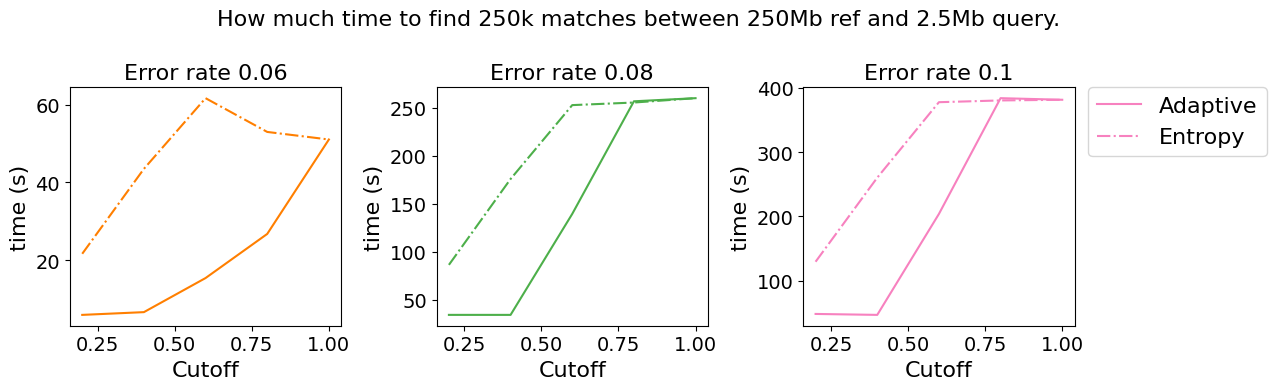

In [225]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches(13, 4)

color = "black"

#ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
#ax2.set_ylabel('missed (%)', color=color)  # we already handled the x-label with ax1
#ax2.tick_params(axis='y', labelcolor=color)

i=0
for j in range(len(er_rates)):
    df = data[data["entropy_cutoff"] == 1.0] 

    er = er_rates[j]
    er_df = df[df["error_rate"] == er]
    er_df = er_df.groupby('adapt_cutoff')[["search time (sec)", "missed (%)", 'adapt_cutoff']].mean()
    
    i=i+1
    color = CB_color_cycle[i]
    ax[j].plot(er_df["adapt_cutoff"], er_df["search time (sec)"], color=color, label = "Adaptive")
    ax[j].set_xlabel('Cutoff')
    ax[j].set_ylabel('time (s)')
                     #, color=color)

    #ax2.plot(er_df["adapt_cutoff"], er_df["missed (%)"], color=color, label = er)

    df = data[data["adapt_cutoff"] == 1.0] 

    er_df = df[df["error_rate"] == er]
    er_df = er_df.groupby('entropy_cutoff')[["search time (sec)", "missed (%)", "entropy_cutoff"]].mean()
    color = CB_color_cycle[i]
    ax[j].plot(er_df["entropy_cutoff"], er_df["search time (sec)"], linestyle = "-.", color=color, label = "Entropy")
    ax[j].set_title("Error rate " +  str(er))

ax[j].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.suptitle("How much time to find 250k matches between 250Mb ref and 2.5Mb query.")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.savefig("250Mb_" + dtype + "_time_vs_cutoff.pdf", dpi=400, bbox_inches='tight')
plt.show()

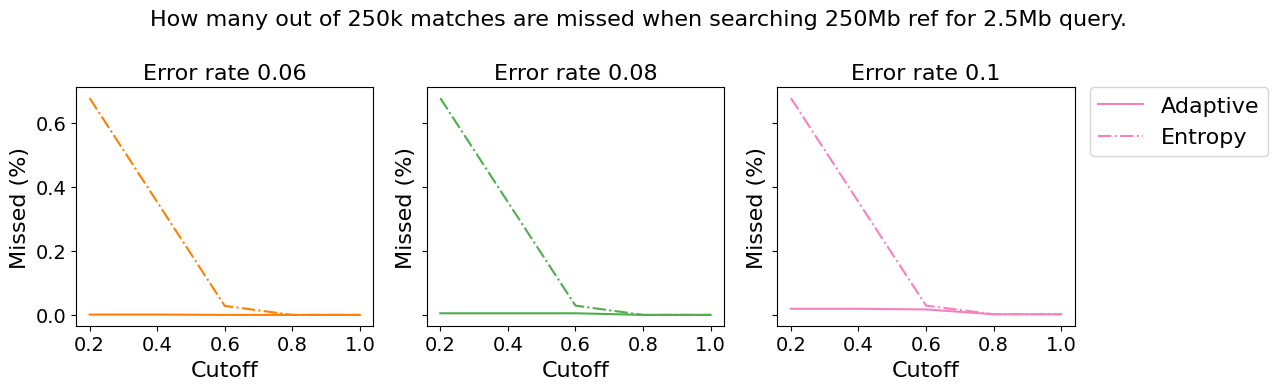

In [226]:
fig, ax = plt.subplots(1, 3, sharey = True)
fig.set_size_inches(13, 4)

color = "black"

#ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
#ax2.set_ylabel('missed (%)', color=color)  # we already handled the x-label with ax1
#ax2.tick_params(axis='y', labelcolor=color)

i=0
for j in range(len(er_rates)):
    df = data[data["entropy_cutoff"] == 1.0] 

    er = er_rates[j]
    er_df = df[df["error_rate"] == er]
    er_df = er_df.groupby('adapt_cutoff')[["search time (sec)", "missed (%)", 'adapt_cutoff']].mean()
    
    i=i+1
    color = CB_color_cycle[i]
    ax[j].plot(er_df["adapt_cutoff"], er_df["missed (%)"], color=color, label = "Adaptive")
    ax[j].set_xlabel('Cutoff')
    ax[j].set_ylabel('Missed (%)')
                     #, color=color)

    #ax2.plot(er_df["adapt_cutoff"], er_df["missed (%)"], color=color, label = er)

    df = data[data["adapt_cutoff"] == 1.0] 

    er_df = df[df["error_rate"] == er]
    er_df = er_df.groupby('entropy_cutoff')[["search time (sec)", "missed (%)", "entropy_cutoff"]].mean()
    color = CB_color_cycle[i]
    ax[j].plot(er_df["entropy_cutoff"], er_df["missed (%)"], linestyle = "-.", color=color, label = "Entropy")
    ax[j].set_title("Error rate " +  str(er))

ax[j].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.suptitle("How many out of 250k matches are missed when searching 250Mb ref for 2.5Mb query.")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.savefig("250Mb_" + dtype + "_missed_vs_cutoff.pdf", dpi=400, bbox_inches='tight')
plt.show()

## Adaptive seeding effectiveness

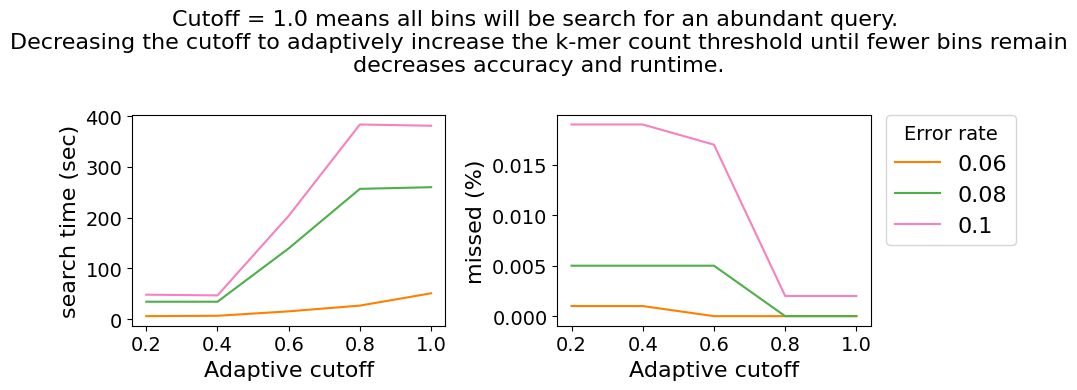

In [228]:
fig, [ax1, ax2] = plt.subplots(1, 2)
fig.set_size_inches(10, 4)

time_color = "black"
ax1.set_ylabel('search time (sec)', color = time_color)
ax1.tick_params(axis='y', labelcolor=time_color)
ax1.set_xlabel("Adaptive cutoff")

missed_color = "black"
#ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylabel('missed (%)', color=missed_color)  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor=missed_color)
ax2.set_xlabel("Adaptive cutoff")    

df = data[data["entropy_cutoff"] == 1.0] 

for j in range(len(er_rates)):
    er = er_rates[j]
    er_df = df[df["error_rate"] == er]
    er_df = er_df.groupby('adapt_cutoff')[["search time (sec)", "missed (%)", 'adapt_cutoff']].mean()
    ax1.plot(er_df["adapt_cutoff"], er_df["search time (sec)"], color=CB_color_cycle[j+1])
    ax2.plot(er_df["adapt_cutoff"], er_df["missed (%)"], color=CB_color_cycle[j+1], label = er)

ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title = "Error rate")

fig.suptitle("Cutoff = 1.0 means all bins will be search for an abundant query. \n"
             "Decreasing the cutoff to adaptively increase the k-mer count threshold until fewer bins remain\n"
             "decreases accuracy and runtime.")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
#fig.savefig("250Mb_" + dtype + "_missed_vs_cutoff.pdf", dpi=400, bbox_inches='tight')
plt.show()